# Mountain Car Reinforcement Learning Comparison

## Table of Contents

1. [Environment Description](#1-environment-description)
2. [Wrappers, Variations, and Shaping](#2-wrappers-variations-and-shaping)
3. [Discrete Agents](#3-discrete-agents)
   - Q-Learning
   - DQN
   - Double DQN
4. [Discrete Agents Comparison](#4-discrete-agents-comparison)
5. [Continuous Agents](#5-continuous-agents)
   - SAC
   - A2C
   - PPO
6. [Continuous Agents Comparison](#6-continuous-agents-comparison)
7. [Best Agents Selection and Analysis](#7-best-agents-selection-and-comparison)


## 1. Environment Description

In [15]:
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

import pandas as pd
import os
import numpy as np
from envs import make_env
from agents import QLearningAgent, DQNAgent, DoubleDQNAgent, SACAgent, A2CAgent, PPOAgent
from core import trainer, evaluator
from core.logger import log_run
from visualization import plots


## 2. Wrappers, Variations, and Shaping

In [16]:
# Shared across both agents
D_VARIANT          = 'discrete_steps'
C_VARIANT          = 'continuous_steps'
SEED             = 0

# Reward shaping options
ENERGY_SHAPING   = True       # potential-based bonus on |velocity|
ENERGY_SCALE     = 1000.0
BEST_POS_SHAPING = True      # sparse bonus for new rightmost position
GOAL_BONUS       = 0     # sparse bonus for reaching the goal (position >= 0.5)

## 3. Discrete Agents

### Q-Learning

In [17]:
# Setting up Environment and Hyperparameters for Q-Learning
ql_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING)
ql_eval_env = make_env(D_VARIANT, seed=SEED + 100)

ql_agent = QLearningAgent(
    ql_env, n_bins=40, lr=0.05, gamma=0.99,
    epsilon=0.6, epsilon_min=0, decay_steps=50_000, seed=SEED,
)


Explanation of hyperparameters

In [18]:
ql_run = f"qlearning_{D_VARIANT}"
_save = f"../runs/{ql_run}/saves/agent.npz"


ql_agent = QLearningAgent.load(_save, ql_env)

log_run(ql_run, "QLearningAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ql_agent.get_config())
ql_logger = trainer.run(ql_env, ql_agent, episodes=1000, run_name=ql_run)
# Saving Agent
ql_agent.save(_save)

Episode 0: reward=-177.7, steps=200, true_obj=200.0, success=False
Episode 100: reward=-194.3, steps=200, true_obj=200.0, success=False
Episode 200: reward=-190.9, steps=198, true_obj=198.0, success=True
Episode 300: reward=-144.8, steps=157, true_obj=157.0, success=True
Episode 400: reward=-160.9, steps=163, true_obj=163.0, success=True
Episode 500: reward=-151.8, steps=155, true_obj=155.0, success=True
Episode 600: reward=-162.7, steps=168, true_obj=168.0, success=True
Episode 700: reward=-191.3, steps=197, true_obj=197.0, success=True
Episode 800: reward=-137.4, steps=149, true_obj=149.0, success=True
Episode 900: reward=-153.8, steps=200, true_obj=200.0, success=False


Eval over 500 episodes: true_obj=200.00 +/- 0.00, success_rate=0.00, shaped_reward=-200.0


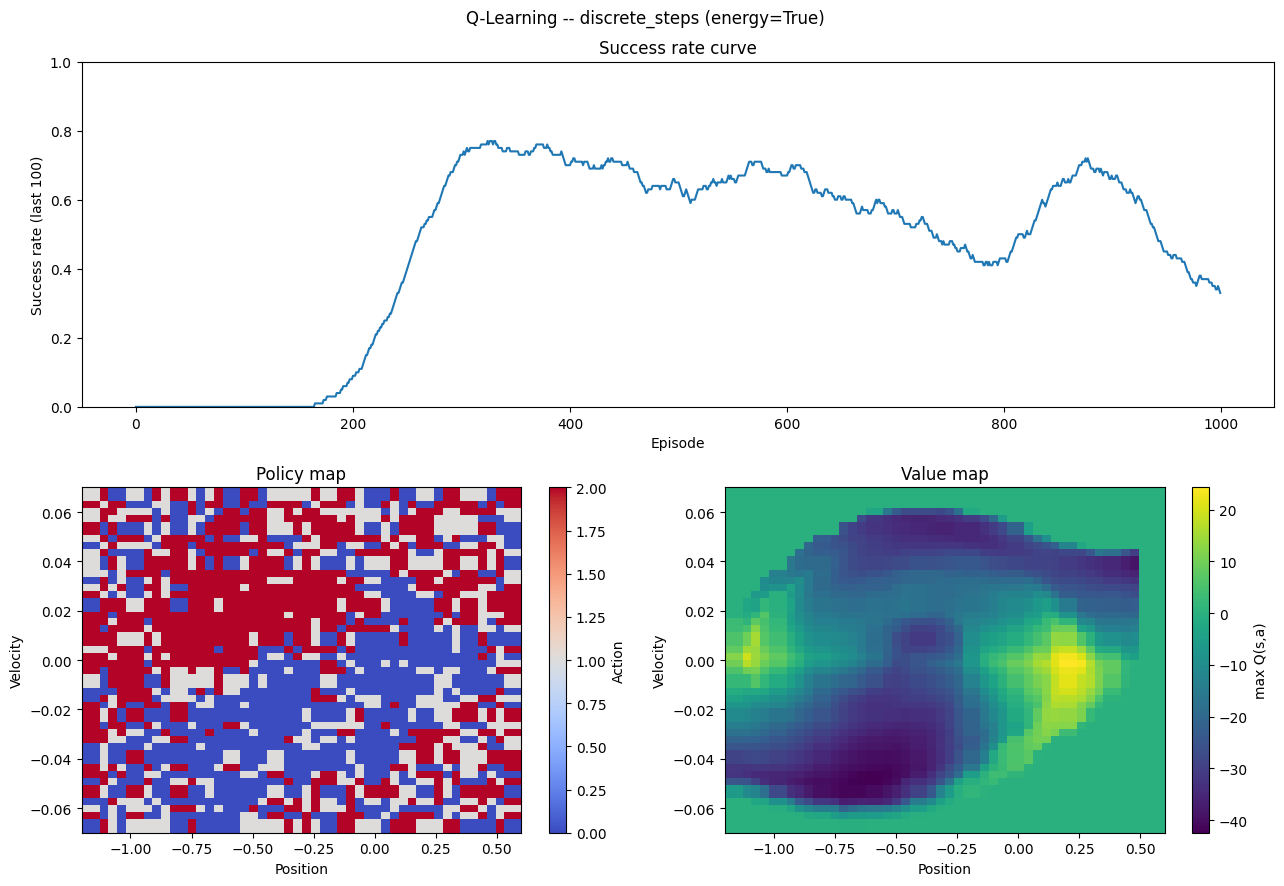

In [34]:
ql_results = evaluator.evaluate(ql_eval_env, ql_agent, n=500, run_name=ql_run)

ql_data = pd.read_csv(f"../runs/{ql_run}/log.csv").to_dict("records")
ql_agent_plot = QLearningAgent.load(f"../runs/{ql_run}/saves/agent.npz", ql_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ql_data, ax=ax_top)
plots.policy_map(ql_agent_plot, ql_eval_env, ax=ax_bl)
plots.value_map(ql_agent_plot, ql_eval_env, ax=ax_br)
fig.suptitle(f"Q-Learning -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


### DQN

In [20]:
# Setting up Environment and Hyperparameters for DQN
dqn_env = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING,
    goal_bonus=GOAL_BONUS,
)
dqn_eval_env = make_env(D_VARIANT, seed=SEED + 100)

dqn_agent = DQNAgent(
    dqn_env,
    lr=1e-3,
    gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000,
    batch_size=100,
    warmup=2500,
    target_update=500,
    hidden=64,
    seed=SEED,
)

Explanation of hyperparameters

In [ ]:
# Running Agent
dqn_run = f"dqn_{D_VARIANT}"
log_run(dqn_run, "DQNAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING,
                    "goal_bonus": GOAL_BONUS},
        agent_config=dqn_agent.get_config())
dqn_logger = trainer.run(dqn_env, dqn_agent, episodes=500, run_name=dqn_run)

# Saving Agent
dqn_agent.save(f"../runs/{dqn_run}/saves/agent.pt")

Episode 0: reward=-197.3, steps=200, true_obj=200.0, success=False
Episode 100: reward=-176.4, steps=200, true_obj=200.0, success=False
Episode 200: reward=-186.7, steps=200, true_obj=200.0, success=False
Episode 300: reward=-137.2, steps=152, true_obj=152.0, success=True


Eval over 50 episodes: true_obj=145.72 +/- 31.61, success_rate=0.76, shaped_reward=-145.7


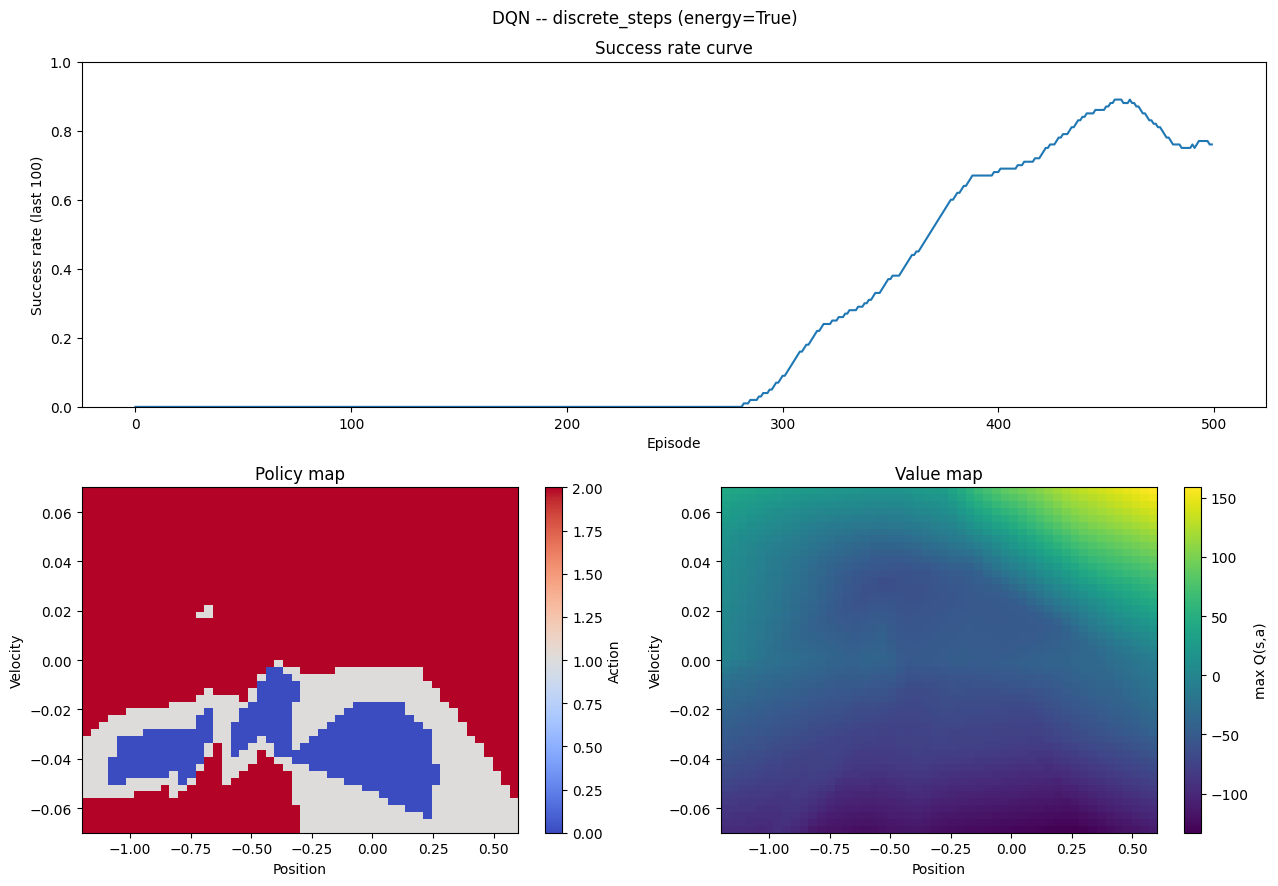

In [33]:
dqn_results = evaluator.evaluate(dqn_eval_env, dqn_agent, n=50, run_name=dqn_run)

dqn_data = pd.read_csv(f"../runs/{dqn_run}/log.csv").to_dict("records")
dqn_agent_plot = DQNAgent.load(f"../runs/{dqn_run}/saves/agent.pt", dqn_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(dqn_data, ax=ax_top)
plots.policy_map(dqn_agent_plot, dqn_eval_env, ax=ax_bl)
plots.value_map(dqn_agent_plot, dqn_eval_env, ax=ax_br)
fig.suptitle(f"DQN -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


### DDQN

In [ ]:
# Setting up Environment and Hyperparameters for Double DQN
ddqn_env      = make_env(
    D_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
ddqn_eval_env = make_env(D_VARIANT, seed=SEED + 100)

ddqn_agent = DoubleDQNAgent(
    ddqn_env, lr=1e-3, gamma=0.99,
    epsilon=0.7, epsilon_min=0, decay_steps=100_000,
    buffer_size=50_000, batch_size=100,
    warmup=2500, target_update=500, hidden=64, seed=SEED,
)


Explanation of hyperparameters

In [ ]:
# Running Agent
ddqn_run = f"ddqn_{D_VARIANT}"
log_run(ddqn_run, "DoubleDQNAgent",
        env_config={"variant": D_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ddqn_agent.get_config())
ddqn_logger = trainer.run(ddqn_env, ddqn_agent, episodes=500, run_name=ddqn_run)

# Saving Agent
ddqn_agent.save(f"../runs/{ddqn_run}/saves/agent.pt")


Episode 0: reward=-197.3, steps=200, true_obj=200.0, success=False
Episode 100: reward=-199.2, steps=200, true_obj=200.0, success=False
Episode 200: reward=-189.0, steps=200, true_obj=200.0, success=False
Episode 300: reward=-151.0, steps=162, true_obj=162.0, success=True
Episode 400: reward=-65.2, steps=92, true_obj=92.0, success=True


Eval over 50 episodes: true_obj=114.50 +/- 17.68, success_rate=0.96, shaped_reward=-114.5


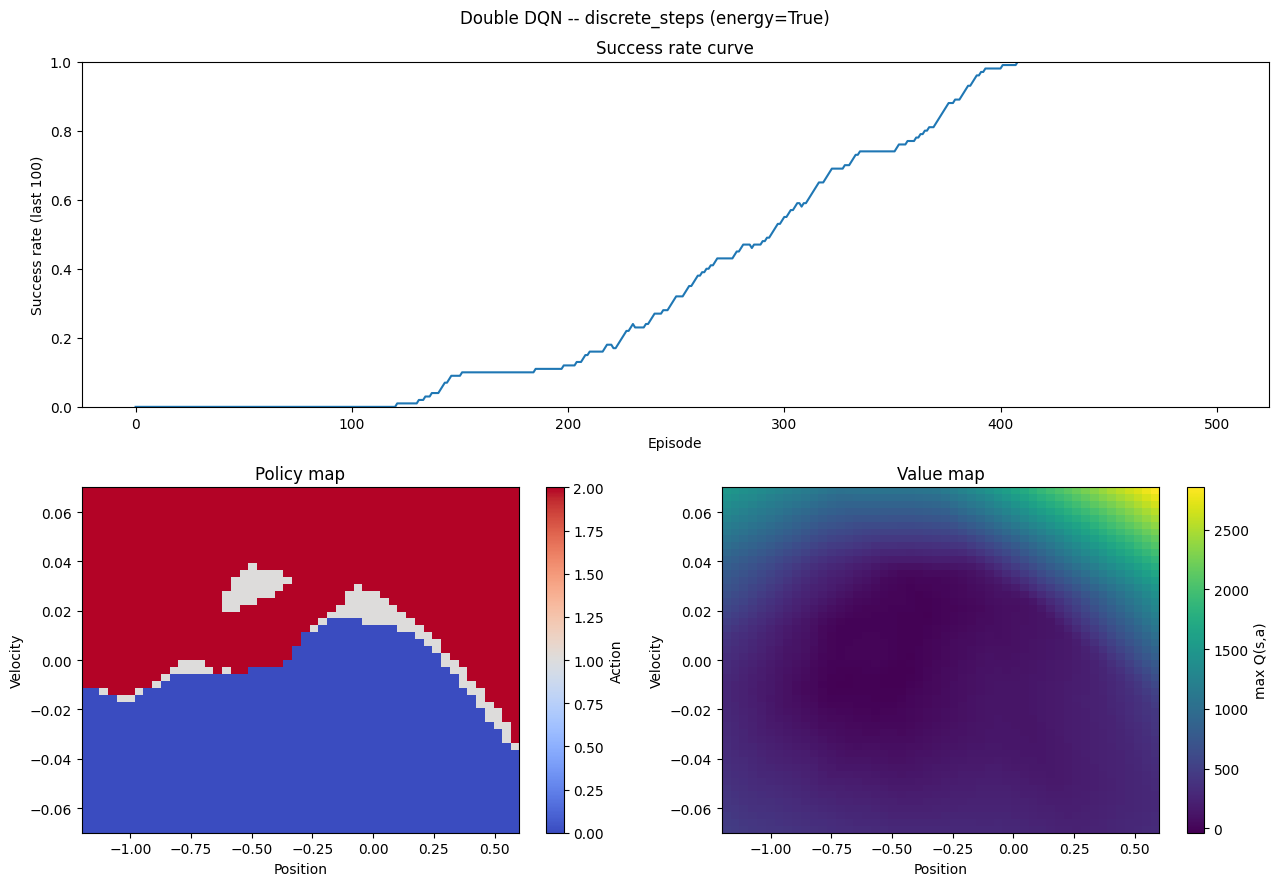

In [32]:
ddqn_results = evaluator.evaluate(ddqn_eval_env, ddqn_agent, n=50, run_name=ddqn_run)

ddqn_data = pd.read_csv(f"../runs/{ddqn_run}/log.csv").to_dict("records")
ddqn_agent_plot = DoubleDQNAgent.load(f"../runs/{ddqn_run}/saves/agent.pt", ddqn_eval_env)

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ddqn_data, ax=ax_top)
plots.policy_map(ddqn_agent_plot, ddqn_eval_env, ax=ax_bl)
plots.value_map(ddqn_agent_plot, ddqn_eval_env, ax=ax_br)
fig.suptitle(f"Double DQN -- {D_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()


## 4. Discrete Agents Comparison

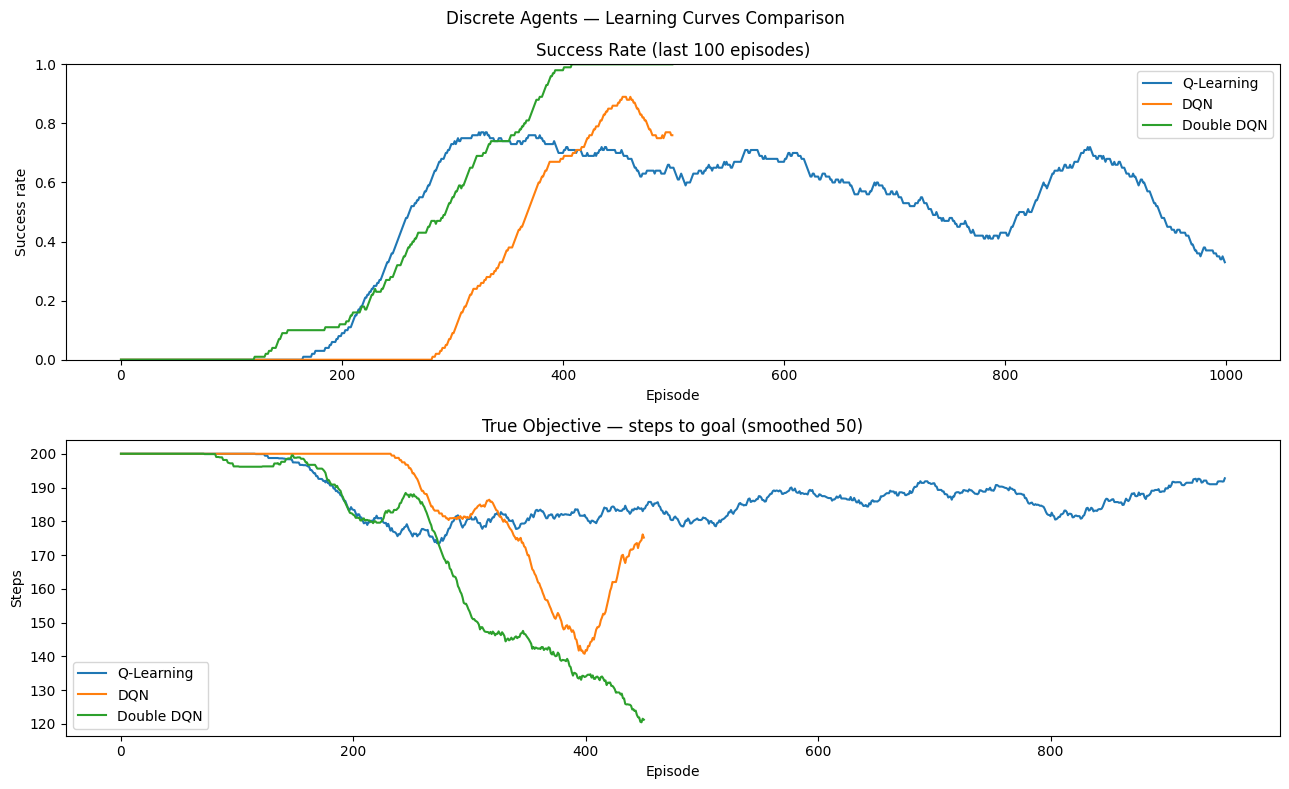

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

for data, label in [
    (ql_data,   "Q-Learning"),
    (dqn_data,  "DQN"),
    (ddqn_data, "Double DQN"),
]:
    sr = [d["success_rate_100"] for d in data if d.get("success_rate_100") is not None]
    ax1.plot(sr, label=label)

ax1.set_title("Success Rate (last 100 episodes)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success rate")
ax1.set_ylim(0, 1)
ax1.legend()

for data, label in [
    (ql_data,   "Q-Learning"),
    (dqn_data,  "DQN"),
    (ddqn_data, "Double DQN"),
]:
    to = [d["true_obj"] for d in data if d.get("true_obj") is not None]
    smoothed = np.convolve(to, np.ones(50) / 50, mode="valid") if len(to) >= 50 else to
    ax2.plot(smoothed, label=label)

ax2.set_title("True Objective — steps to goal (smoothed 50)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.legend()

fig.suptitle("Discrete Agents — Learning Curves Comparison")
plt.tight_layout()
plt.show()

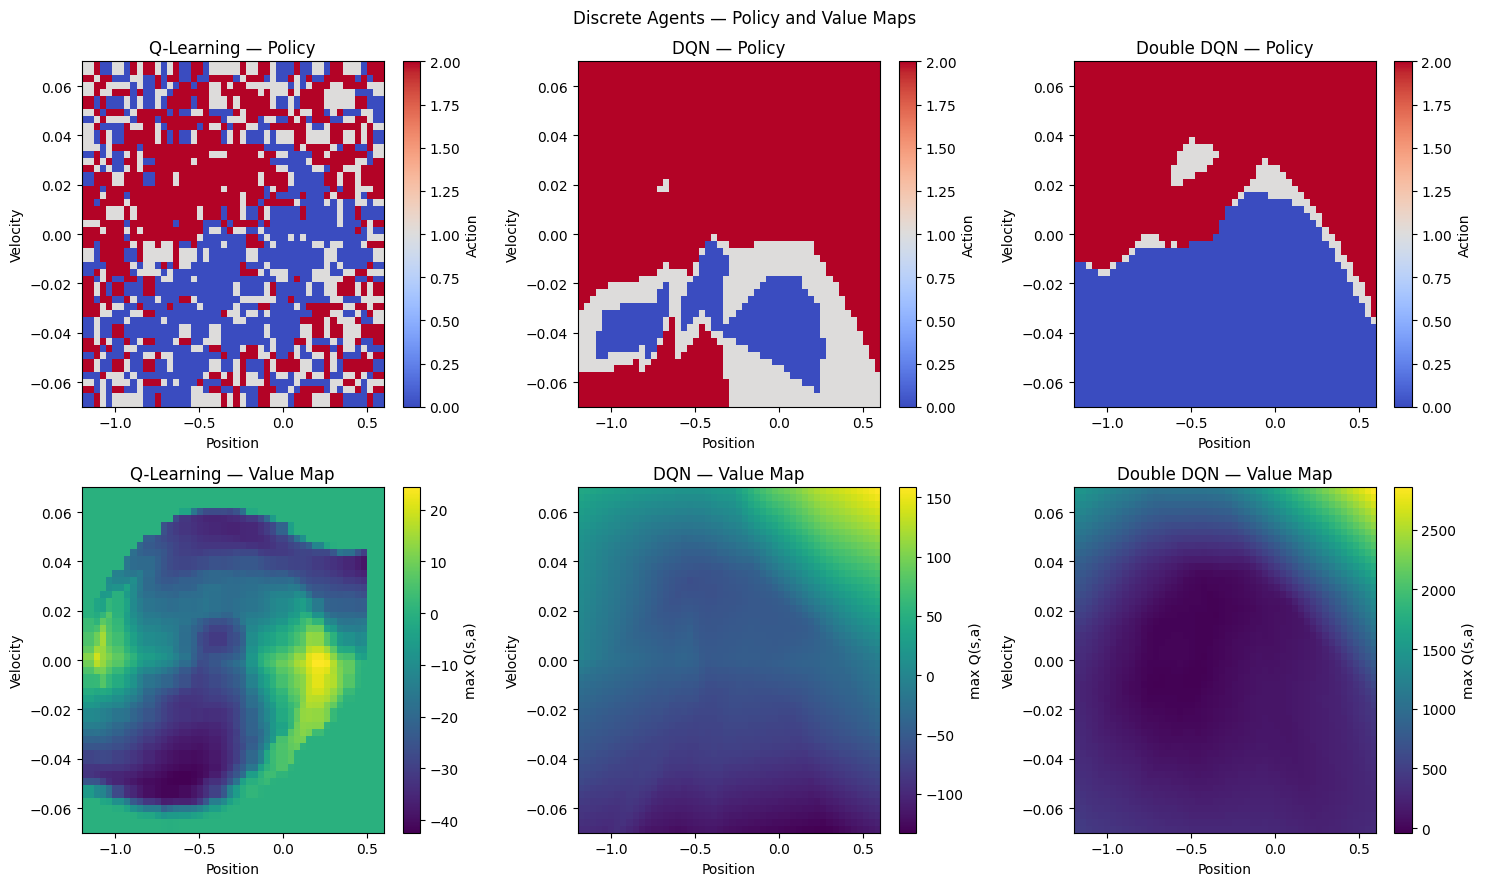

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, (agent, env, name) in enumerate([
    (ql_agent_plot,   ql_eval_env,   "Q-Learning"),
    (dqn_agent_plot,  dqn_eval_env,  "DQN"),
    (ddqn_agent_plot, ddqn_eval_env, "Double DQN"),
]):
    plots.policy_map(agent, env, ax=axes[0, j])
    axes[0, j].set_title(f"{name} — Policy")
    plots.value_map(agent, env, ax=axes[1, j])
    axes[1, j].set_title(f"{name} — Value Map")

fig.suptitle("Discrete Agents — Policy and Value Maps")
plt.tight_layout()
plt.show()

## 5. Continuous Agents

### SAC

In [35]:
# Setting up Environment and Hyperparameters for SAC
sac_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
sac_eval_env = make_env(C_VARIANT, seed=SEED + 100)

sac_agent = SACAgent(
    sac_env, lr=3e-4, gamma=0.99,
    buffer_size=100_000, batch_size=256, warmup=1000, seed=SEED,
)


Explanation of hyperparameters

In [36]:
# Running Agent
sac_run = f"sac_{C_VARIANT}"
log_run(sac_run, "SACAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=sac_agent.get_config())
sac_logger = trainer.run(sac_env, sac_agent, episodes=200, run_name=sac_run)

# Saving Agent
sac_agent.save(f"../runs/{sac_run}/saves/agent")


Episode 0: reward=-1073.0, steps=999, true_obj=999.0, success=False
Episode 100: reward=11.3, steps=102, true_obj=102.0, success=True


In [38]:
sac_results = evaluator.evaluate(sac_eval_env, sac_agent, n=50, run_name=sac_run)

sac_data = pd.read_csv(f"../runs/{sac_run}/log.csv").to_dict("records")

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
plots.entropy_heatmap(sac_agent, sac_eval_env, ax=ax)
fig.suptitle(f"SAC -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

### A2C

In [39]:
# Setting up Environment and Hyperparameters for A2C
a2c_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
a2c_eval_env = make_env(C_VARIANT, seed=SEED + 100)

a2c_agent = A2CAgent(
    a2c_env, lr=7e-4, gamma=0.99,
    n_steps=5, ent_coef=0.01, vf_coef=0.5, seed=SEED,
)

Explanation of hyperparameters

In [40]:
# Running Agent
a2c_run = f"a2c_{C_VARIANT}"
log_run(a2c_run, "A2CAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=a2c_agent.get_config())
a2c_logger = trainer.run(a2c_env, a2c_agent, episodes=300, run_name=a2c_run)

# Saving Agent
a2c_agent.save(f"../runs/{a2c_run}/saves/agent")

Episode 0: reward=-1150.0, steps=999, true_obj=999.0, success=False
Episode 100: reward=-135.9, steps=161, true_obj=161.0, success=True
Episode 200: reward=-21.9, steps=120, true_obj=120.0, success=True


Eval over 50 episodes: true_obj=123.94 +/- 29.67, success_rate=1.00, shaped_reward=-48.7


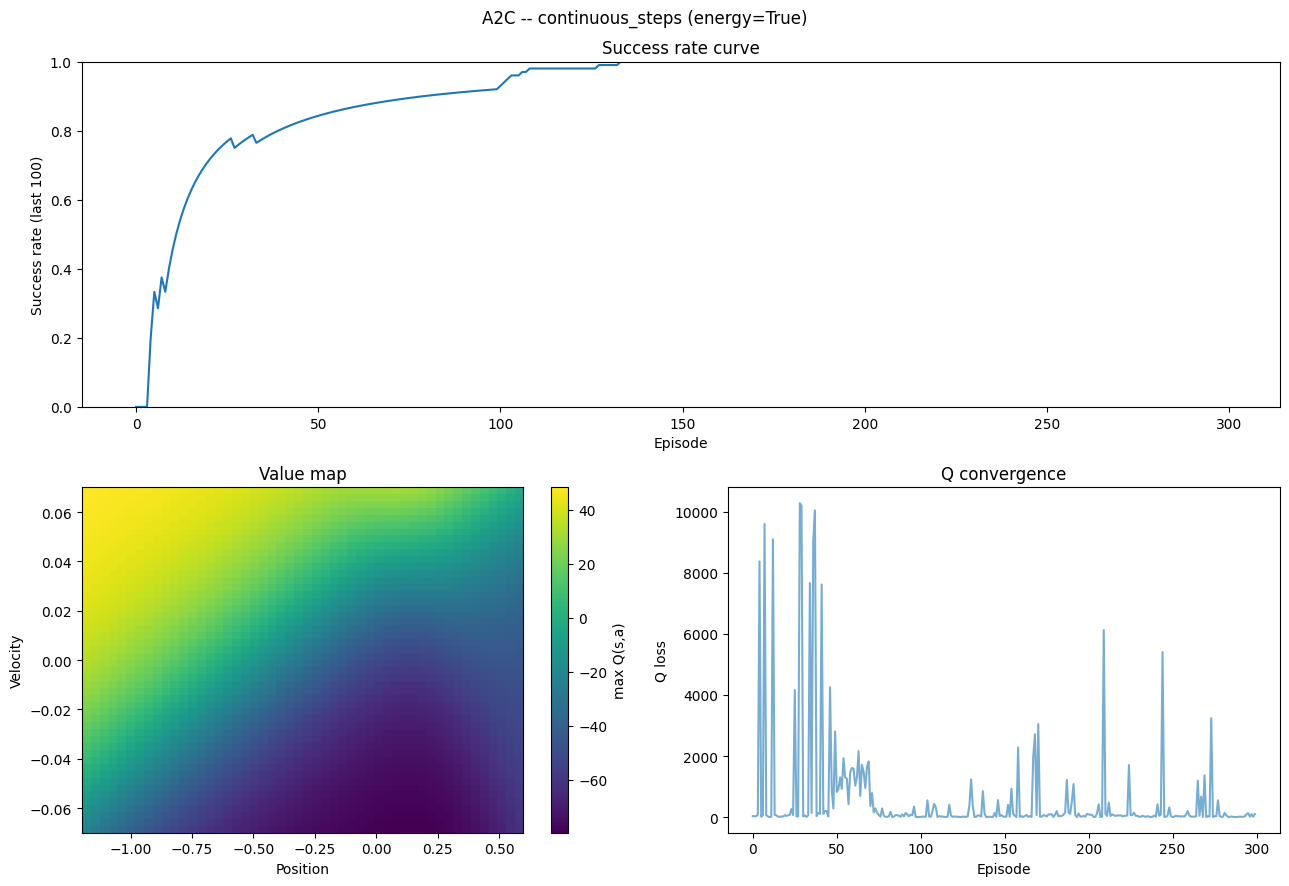

In [41]:
a2c_results = evaluator.evaluate(a2c_eval_env, a2c_agent, n=50, run_name=a2c_run)

a2c_data = pd.read_csv(f"../runs/{a2c_run}/log.csv").to_dict("records")

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(a2c_data, ax=ax_top)
plots.value_map(a2c_agent, a2c_eval_env, ax=ax_bl)
plots.q_convergence(a2c_data, ax=ax_br)
fig.suptitle(f"A2C -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

### PPO

In [42]:
# Setting up Environment and Hyperparameters for PPO
ppo_env      = make_env(
    C_VARIANT, seed=SEED,
    energy_shaping=ENERGY_SHAPING, energy_scale=ENERGY_SCALE,
    best_pos_shaping=BEST_POS_SHAPING, goal_bonus=GOAL_BONUS,
)
ppo_eval_env = make_env(C_VARIANT, seed=SEED + 100)

ppo_agent = PPOAgent(
    ppo_env, lr=3e-4, gamma=0.99,
    n_steps=2048, batch_size=64, n_epochs=10, seed=SEED,
)

Explanation of hyperparameters

In [43]:
# Running Agent
ppo_run = f"ppo_{C_VARIANT}"
log_run(ppo_run, "PPOAgent",
        env_config={"variant": C_VARIANT, "seed": SEED,
                    "energy_shaping": ENERGY_SHAPING, "energy_scale": ENERGY_SCALE,
                    "best_pos_shaping": BEST_POS_SHAPING, "goal_bonus": GOAL_BONUS},
        agent_config=ppo_agent.get_config())
ppo_logger = trainer.run(ppo_env, ppo_agent, episodes=300, run_name=ppo_run)

# Saving Agent
ppo_agent.save(f"../runs/{ppo_run}/saves/agent")

Episode 0: reward=-1185.6, steps=999, true_obj=999.0, success=False
Episode 100: reward=-302.7, steps=357, true_obj=357.0, success=True
Episode 200: reward=-134.8, steps=216, true_obj=216.0, success=True


Eval over 50 episodes: true_obj=177.02 +/- 48.10, success_rate=1.00, shaped_reward=-93.7


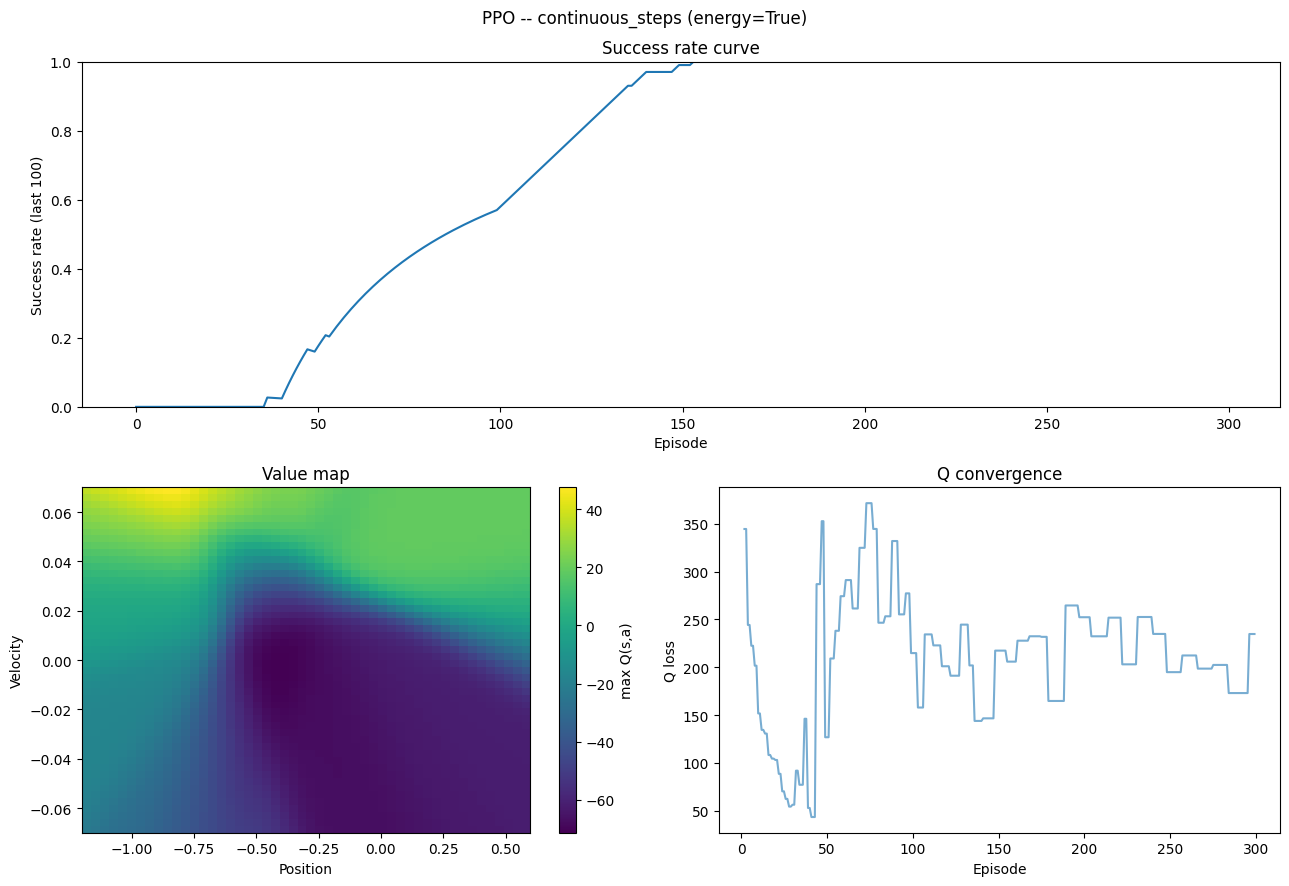

In [46]:
ppo_results = evaluator.evaluate(ppo_eval_env, ppo_agent, n=50, run_name=ppo_run)

ppo_data = pd.read_csv(f"../runs/{ppo_run}/log.csv").to_dict("records")

fig = plt.figure(figsize=(13, 9))
ax_top = fig.add_subplot(2, 1, 1)
ax_bl  = fig.add_subplot(2, 2, 3)
ax_br  = fig.add_subplot(2, 2, 4)
plots.success_rate_curve(ppo_data, ax=ax_top)
plots.value_map(ppo_agent, ppo_eval_env, ax=ax_bl)
plots.q_convergence(ppo_data, ax=ax_br)
fig.suptitle(f"PPO -- {C_VARIANT} (energy={ENERGY_SHAPING})")
plt.tight_layout()
plt.show()

## 6. Continuous Agents Comparison

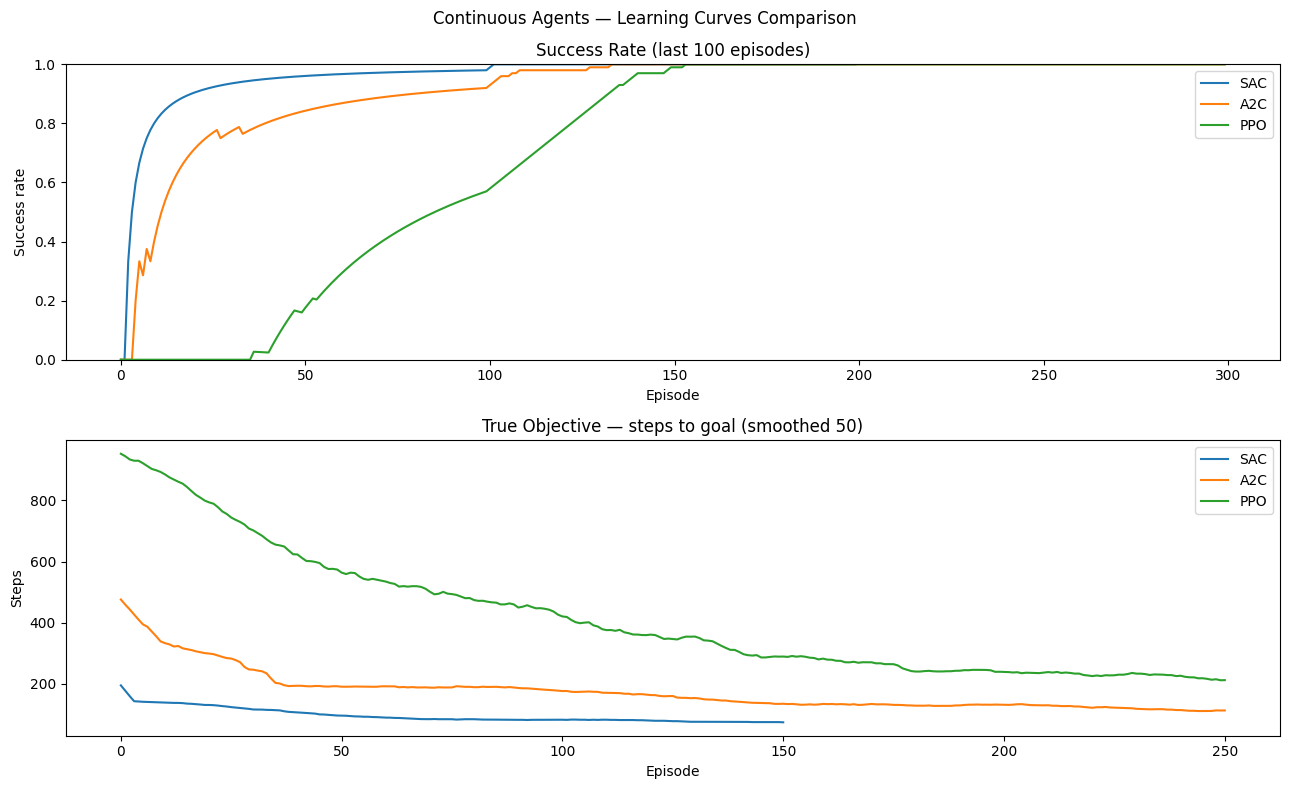

In [47]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8))

for data, label in [
    (sac_data, "SAC"),
    (a2c_data, "A2C"),
    (ppo_data, "PPO"),
]:
    sr = [d["success_rate_100"] for d in data if d.get("success_rate_100") is not None]
    ax1.plot(sr, label=label)

ax1.set_title("Success Rate (last 100 episodes)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success rate")
ax1.set_ylim(0, 1)
ax1.legend()

for data, label in [
    (sac_data, "SAC"),
    (a2c_data, "A2C"),
    (ppo_data, "PPO"),
]:
    to = [d["true_obj"] for d in data if d.get("true_obj") is not None]
    smoothed = np.convolve(to, np.ones(50) / 50, mode="valid") if len(to) >= 50 else to
    ax2.plot(smoothed, label=label)

ax2.set_title("True Objective — steps to goal (smoothed 50)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Steps")
ax2.legend()

fig.suptitle("Continuous Agents — Learning Curves Comparison")
plt.tight_layout()
plt.show()

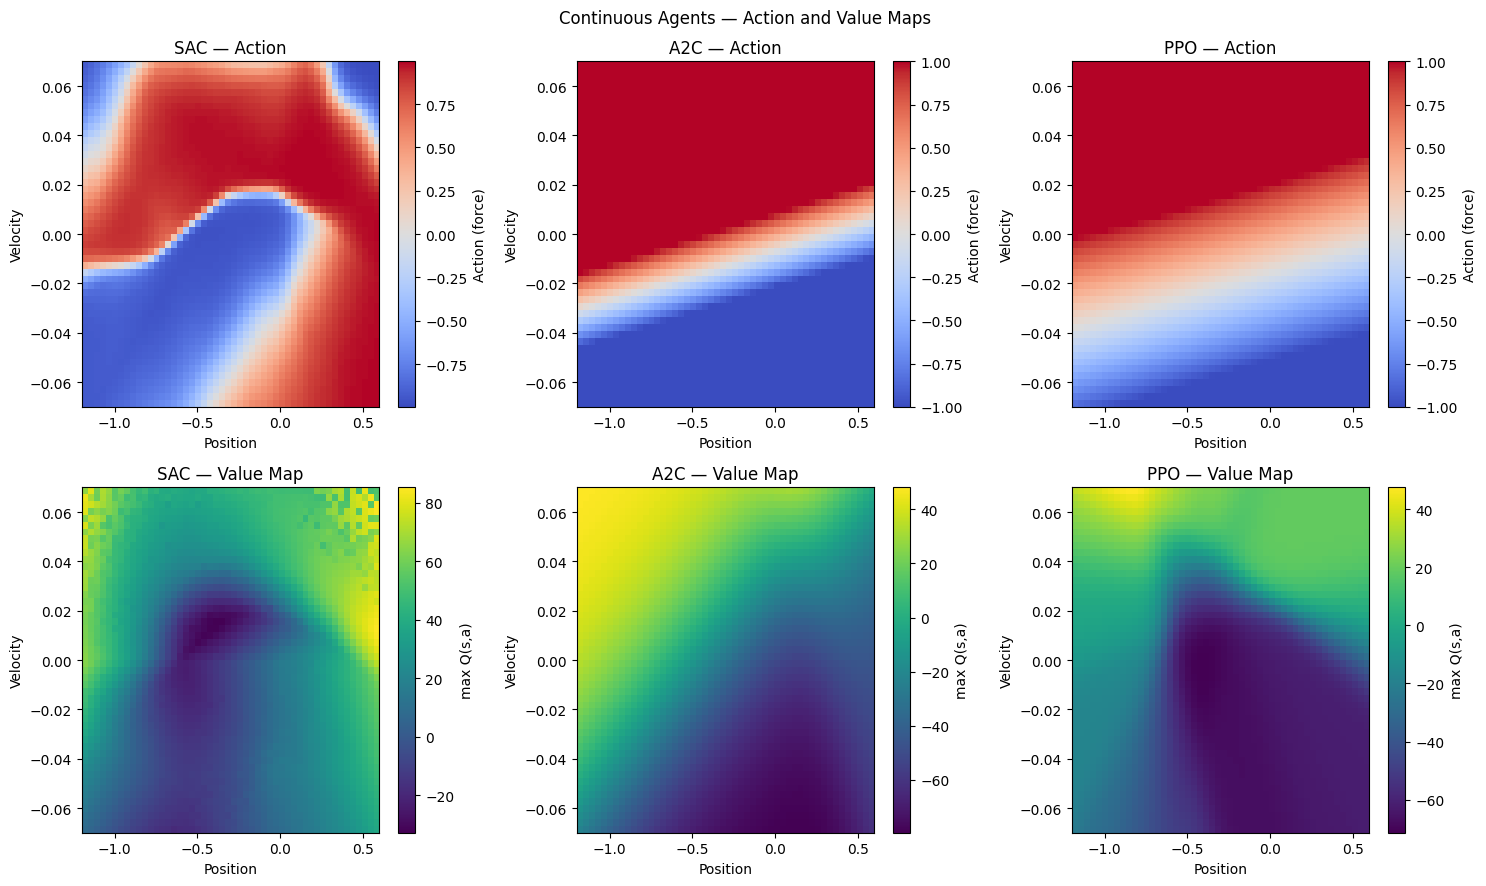

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for j, (agent, env, name) in enumerate([
    (sac_agent, sac_eval_env, "SAC"),
    (a2c_agent, a2c_eval_env, "A2C"),
    (ppo_agent, ppo_eval_env, "PPO"),
]):
    plots.action_heatmap(agent, env, ax=axes[0, j])
    axes[0, j].set_title(f"{name} — Action")
    plots.value_map(agent, env, ax=axes[1, j])
    axes[1, j].set_title(f"{name} — Value Map")

fig.suptitle("Continuous Agents — Action and Value Maps")
plt.tight_layout()
plt.show()

## 7. Best Agents Selection and Comparison